<a href="https://colab.research.google.com/github/EmePin/Analisis-de-datos/blob/main/Comparativo_INEGI_2010_2020_LENGUAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparativo Nacional de los Censos de población y vivienda INEGI 2010 y 2020 sobre Lenguas Originarias

In [ ]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# se monta el contenido del drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Lee el archivo CSV
df_00_2010 = pd.read_csv('/content/drive/MyDrive/COLAB_BD/BD_LENGUAS_2010_2020/iter_00_cpv2010/conjunto_de_datos/iter_00_cpv2010.csv', encoding='utf-8')

# Muestra (number_of_rows, number_of_columns).
print(df_00_2010.shape)
# Muestra las primeras filas del DataFrame
df_00_2010.head()

(198488, 200)


,entidad,nom_ent,mun,nom_mun,loc,nom_loc,longitud,latitud,altitud,pobtot,...,vph_radio,vph_tv,vph_refri,vph_lavad,vph_autom,vph_pc,vph_telef,vph_cel,vph_inter,tam_loc
0,0,Total nacional,0,Total nacional,0,Total nacional,NaN,NaN,NaN,112336538,...,22373499,26048531,23091296,18692852,12429083,8279619,12161965,18318374,6004315,NaN
1,0,Total nacional,0,Total nacional,9998,Localidades de una vivienda,NaN,NaN,NaN,260087,...,43368,38574,29064,19361,27168,3435,3973,30417,1418,NaN
2,0,Total nacional,0,Total nacional,9999,Localidades de dos viviendas,NaN,NaN,NaN,173056,...,26213,23519,17793,12413,15497,2193,2530,16841,940,NaN
3,1,Aguascalientes,0,Total de la entidad Aguascalientes,0,Total de la Entidad,NaN,NaN,NaN,1184996,...,256790,282484,264623,238954,171795,99579,137911,208209,66075,NaN
4,1,Aguascalientes,0,Total de la entidad Aguascalientes,9998,Localidades de una vivienda,NaN,NaN,NaN,3395,...,658,676,537,449,477,97,48,511,36,NaN


In [ ]:
# Veamos las variables categóricas y las numéricas
df_00_2010.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198488 entries, 0 to 198487
Columns: 200 entries, entidad to tam_loc
dtypes: float64(4), int64(6), object(190)
memory usage: 302.9+ MB


In [ ]:
# Lee el archivo CSV
df_00_2020 = pd.read_csv('/content/drive/MyDrive/COLAB_BD/BD_LENGUAS_2010_2020/iter_00_cpv2020/conjunto_de_datos/conjunto_de_datos_iter_00CSV20.csv', encoding='utf-8')

# Muestra (number_of_rows, number_of_columns).
print(df_00_2020.shape)
# Muestra las primeras filas del DataFrame
df_00_2020.head()

<ipython-input-175-e4a109cd77b8>:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_00_2020 = pd.read_csv('/content/drive/MyDrive/COLAB_BD/BD_LENGUAS_2010_2020/iter_00_cpv2020/conjunto_de_datos/conjunto_de_datos_iter_00CSV20.csv', encoding='utf-8')


(195662, 286)


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,...,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
0,0,Total nacional,0,Total nacional,0,Total nacional,NaN,NaN,NaN,126014024,...,30775898,18307193,15211306,6616141,4047100,1788552,3170894,15108204,852871,*
1,0,Total nacional,0,Total nacional,9998,Localidades de una vivienda,NaN,NaN,NaN,250354,...,47005,8385,18981,1732,1113,12775,14143,51293,7154,*
2,0,Total nacional,0,Total nacional,9999,Localidades de dos viviendas,NaN,NaN,NaN,147125,...,25581,5027,11306,971,708,8247,10065,29741,5283,*
3,1,Aguascalientes,0,Total de la entidad Aguascalientes,0,Total de la Entidad,NaN,NaN,NaN,1425607,...,359895,236003,174089,98724,70126,6021,15323,128996,1711,*
4,1,Aguascalientes,0,Total de la entidad Aguascalientes,9998,Localidades de una vivienda,NaN,NaN,NaN,3697,...,732,205,212,48,41,39,62,530,20,*


In [ ]:
# Veamos las variables categóricas y las numéricas
df_00_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195662 entries, 0 to 195661
Columns: 286 entries, ENTIDAD to TAMLOC
dtypes: int64(6), object(280)
memory usage: 426.9+ MB


In [ ]:
# Define las columnas a conservar (en minúsculas)
columnas_a_conservar_minusculas = [col.lower() for col in ['entidad', 'nom_ent', 'mun', 'nom_mun', 'loc', 'nom_loc', 'pobtot', 'p3ym_hli', 'p3hlinhe', 'p3hli_he']]

# Función para procesar el DataFrame
def procesar_dataframe(df, año):
    # Convierte todos los nombres de las columnas a minúsculas
    df.columns = [col.lower() for col in df.columns]
    # Selecciona solo las columnas deseadas
    columnas_seleccionadas = [col for col in df.columns if col in columnas_a_conservar_minusculas]
    df_seleccionado = df[columnas_seleccionadas].copy()
    # Agrega la columna 'año'
    df_seleccionado['año'] = año
    return df_seleccionado

# Procesa ambos DataFrames
df_2010_procesado = procesar_dataframe(df_00_2010, 2010) # Usamos df_00_2010 como mencionaste
df_2020_procesado = procesar_dataframe(df_00_2020, 2020)

# Concatena los DataFrames
df_combinado = pd.concat([df_2010_procesado, df_2020_procesado], ignore_index=True)
df_con_asterisco = df_combinado[~df_combinado['loc'].isin([0, 9998,9999])].copy()
df_con_asterisco.to_csv('/content/drive/MyDrive/COLAB_BD/BD_LENGUAS_2010_2020/df00_combinado_con_asterisco.csv', index=False, encoding='utf-8')


In [ ]:
# Asegurémonos de que las columnas necesarias estén en el DataFrame y sean numéricas
columnas_numericas = ['pobtot', 'p3ym_hli', 'p3hlinhe', 'p3hli_he', 'año', 'entidad', 'nom_ent']

for col in ['pobtot', 'p3ym_hli', 'p3hlinhe', 'p3hli_he']:
    df_con_asterisco[col] = pd.to_numeric(df_con_asterisco[col], errors='coerce')


# 1. Calcular Totales Nacionales y Estatales de Población Total
pobtot_por_año_entidad = df_con_asterisco.groupby(['año', 'entidad', 'nom_ent'])['pobtot'].sum().reset_index()

# 2. Calcular Porcentajes de Hablantes de Lengua Indígena
def calcular_porcentajes(grupo):
    total_poblacion = grupo['pobtot'].sum()
    habla_indigena = grupo['p3ym_hli'].sum()
    solo_indigena = grupo['p3hlinhe'].sum()
    habla_indigena_espanol = grupo['p3hli_he'].sum()

    porcentaje_habla_indigena = (habla_indigena / total_poblacion) * 100 if total_poblacion > 0 else 0
    porcentaje_bilingue = (habla_indigena_espanol / total_poblacion) * 100 if total_poblacion > 0 else 0
    porcentaje_solo_indigena = (solo_indigena / total_poblacion) * 100 if total_poblacion > 0 else 0

    return pd.Series({
        'total_poblacion': total_poblacion,
        'habla_lengua_indigena': habla_indigena,
        'habla_indigena_y_espanol': habla_indigena_espanol,
        'solo_habla_indigena': solo_indigena,
        'porcentaje_habla_indigena': porcentaje_habla_indigena,
        'porcentaje_bilingue': porcentaje_bilingue,
        'porcentaje_solo_indigena': porcentaje_solo_indigena
    })

# Calcular a nivel nacional
analisis_nacional = df_con_asterisco.groupby('año').apply(calcular_porcentajes).reset_index()
print("\nAnálisis Nacional de Hablantes de Lengua Indígena por Año:\n", analisis_nacional)

# Calcular a nivel estatal
analisis_estatal = df_con_asterisco.groupby(['año', 'entidad', 'nom_ent']).apply(calcular_porcentajes).reset_index()
print("\nAnálisis Estatal de Hablantes de Lengua Indígena por Año:\n", analisis_estatal)


Análisis Nacional de Hablantes de Lengua Indígena por Año:
     año  total_poblacion  habla_lengua_indigena  habla_indigena_y_espanol  \
0  2010      112336538.0              6867026.0                 5526095.0   
1  2020      126014024.0              7319495.0                 6385861.0   

   solo_habla_indigena  porcentaje_habla_indigena  porcentaje_bilingue  \
0            1088645.0                   6.112905             4.919232   
1             860162.0                   5.808477             5.067580   

   porcentaje_solo_indigena  
0                  0.969093  
1                  0.682592  

Análisis Estatal de Hablantes de Lengua Indígena por Año:
      año  entidad                          nom_ent  total_poblacion  \
0   2010        1                   Aguascalientes        1184996.0   
1   2010        2                  Baja California        3155070.0   
2   2010        3              Baja California Sur         637026.0   
3   2010        4                         Campeche

<ipython-input-214-f6247105fbb0>:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analisis_nacional = df_con_asterisco.groupby('año').apply(calcular_porcentajes).reset_index()
<ipython-input-214-f6247105fbb0>:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analisis_estatal = df_con_asterisco.groupby(['año', 'entidad', 'nom_ent']).apply(calcular_porcentajes).reset_index()


In [ ]:
# Filtrar el DataFrame analisis_estatal para Oaxaca
analisis_Oaxaca = analisis_estatal[analisis_estatal['nom_ent'] == 'Oaxaca'].copy()

# Imprimir el resultado para Oaxaca
print("\nAnálisis de Hablantes de Lengua Indígena por Año en Oaxaca:\n", analisis_Oaxaca)


Análisis de Hablantes de Lengua Indígena por Año en Oaxaca:
      año  entidad nom_ent  total_poblacion  habla_lengua_indigena  \
19  2010       20  Oaxaca        3801962.0              1199742.0   
51  2020       20  Oaxaca        4132148.0              1218946.0   

    habla_indigena_y_espanol  solo_habla_indigena  porcentaje_habla_indigena  \
19                  974187.0             206779.0                  31.555865   
51                 1078909.0             133869.0                  29.499089   

    porcentaje_bilingue  porcentaje_solo_indigena  
19            25.623270                  5.438745  
51            26.110125                  3.239695  


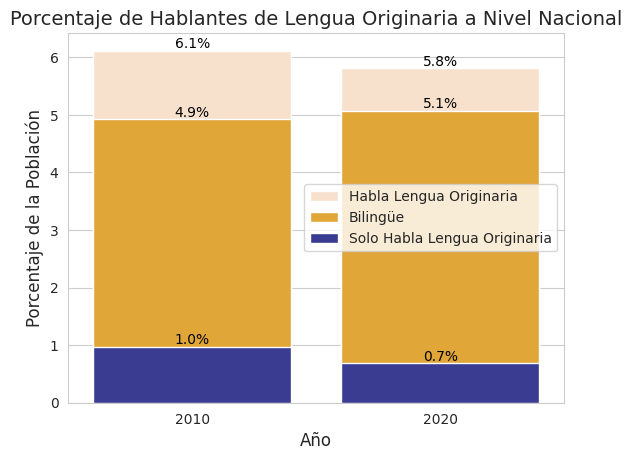

In [ ]:
# Define los colores en formato hexadecimal
color_habla_indigena = '#FEE0C6'
color_bilingue = '#FDAE1C'  # Un tono más claro para contrastar
color_solo_indigena = '#2b2e9e' # Otro tono claro

sns.barplot(x='año', y='porcentaje_habla_indigena', data=analisis_nacional, label='Habla Lengua Originaria', color=color_habla_indigena)
sns.barplot(x='año', y='porcentaje_bilingue', data=analisis_nacional, label='Bilingüe', color=color_bilingue)
sns.barplot(x='año', y='porcentaje_solo_indigena', data=analisis_nacional, label='Solo Habla Lengua Originaria', color=color_solo_indigena)

plt.xlabel('Año', fontsize=12)
plt.ylabel('Porcentaje de la Población', fontsize=12)
plt.title('Porcentaje de Hablantes de Lengua Originaria a Nivel Nacional', fontsize=14)
plt.legend()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Agregar valores de porcentaje encima de las barras
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                        textcoords='offset points')

plt.show()

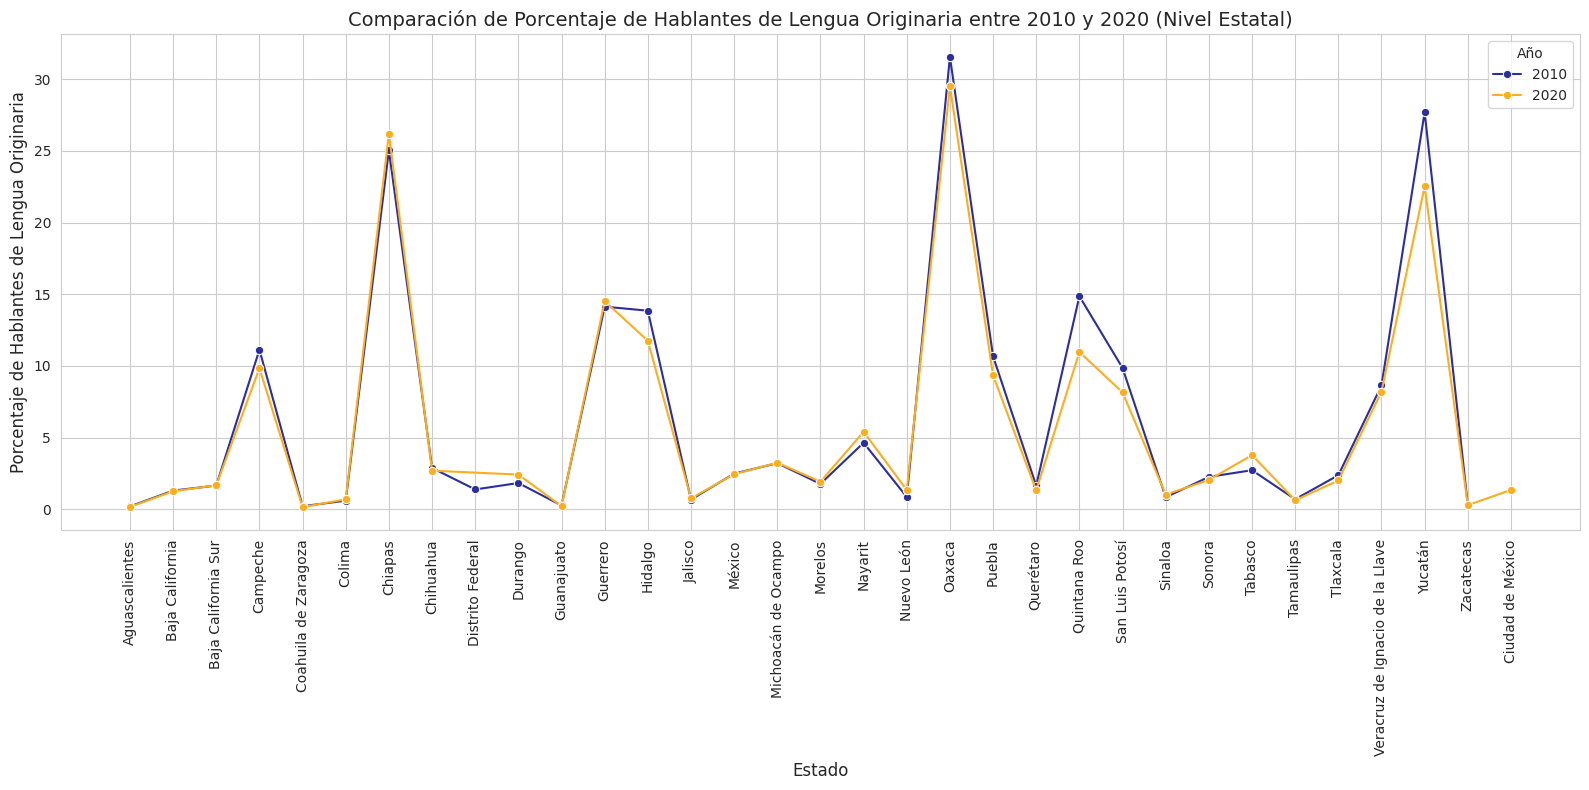

In [ ]:


# Filtra los datos para 2010 y 2020
analisis_estatal_2010_2020 = analisis_estatal[analisis_estatal['año'].isin([2010, 2020])]

# Define los colores primario y secundario
color_primario = '#2b2e9e'
color_secundario = '#FDAE1C'

# Gráfico de líneas para el porcentaje de hablantes de lengua indígena a nivel estatal
plt.figure(figsize=(16, 8))
sns.lineplot(x='nom_ent', y='porcentaje_habla_indigena', hue='año', data=analisis_estatal_2010_2020, marker='o', palette=[color_primario, color_secundario])
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Porcentaje de Hablantes de Lengua Originaria', fontsize=12)
plt.title('Comparación de Porcentaje de Hablantes de Lengua Originaria entre 2010 y 2020 (Nivel Estatal)', fontsize=14)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Año', title_fontsize=10, fontsize=10)
plt.tight_layout()
plt.show()

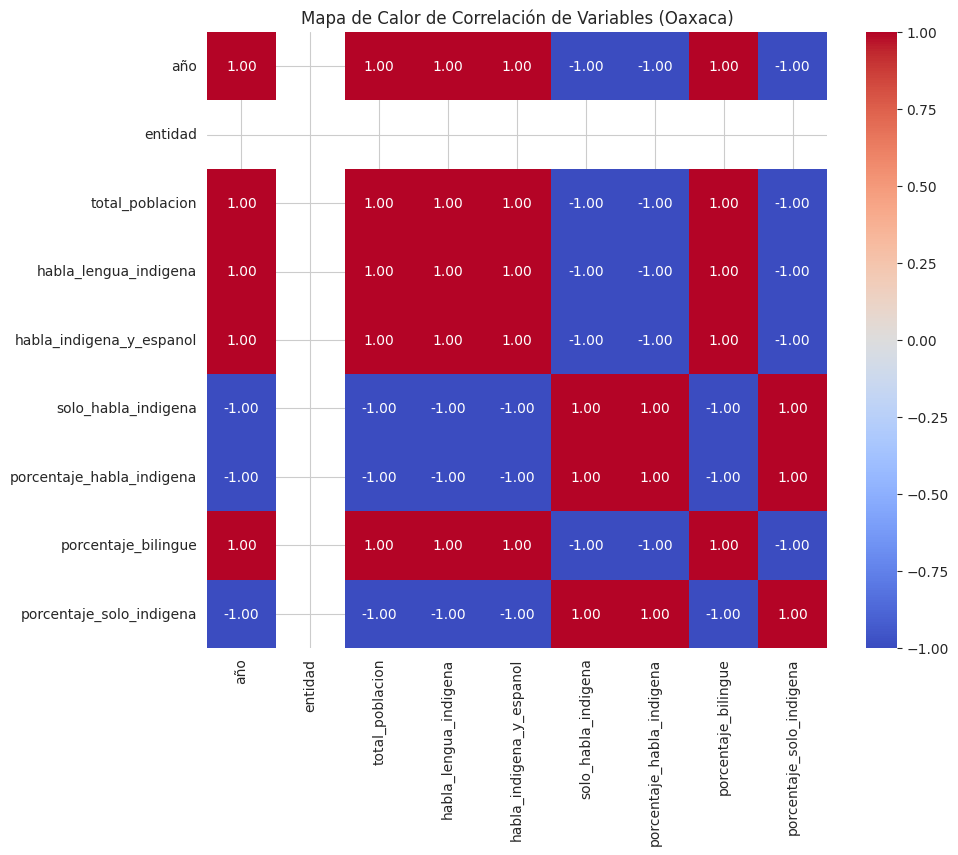

In [ ]:
# Mapa de calor para la correlación entre variables en Oaxaca (si hay suficientes variables numéricas)
# Verifica que analisis_Oaxaca tenga al menos dos columnas numéricas. De ser así, crea el mapa de calor:

numeric_cols_oaxaca = analisis_Oaxaca.select_dtypes(include=['number']).columns.tolist()

if len(numeric_cols_oaxaca) >= 2:
  plt.figure(figsize=(10,8))
  correlation_matrix = analisis_Oaxaca[numeric_cols_oaxaca].corr()
  sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
  plt.title("Mapa de Calor de Correlación de Variables (Oaxaca)")
  plt.show()
else:
    print("No hay suficientes columnas numéricas en el DataFrame para crear el mapa de calor.")


In [ ]:
# Crear las gráficas circulares para Oaxaca
for index, row in analisis_Oaxaca.iterrows():
    año = row['año']
    labels = ['Habla lengua indígena', 'Habla indígena y español', 'Solo habla indígena']
    sizes = [row['porcentaje_habla_indigena'], row['porcentaje_bilingue'], row['porcentaje_solo_indigena']]

    plt.figure(figsize=(8, 8))  # Ajusta el tamaño de la figura
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title(f'Porcentaje de hablantes de lengua indígena en Oaxaca - {año}')
    plt.axis('equal')  # Para asegurar un círculo perfecto
    plt.show()


In [ ]:
# Función para crear el gráfico circular
def crear_grafico_circular(df, año, entidad):
    # Filtrar por año y entidad
    df_filtrado = df[(df['año'] == año) & (df['nom_ent'] == entidad)]

    if not df_filtrado.empty:
        # Obtener los valores para el gráfico
        labels = ['Habla lengua indígena', 'Habla indígena y español', 'Solo habla indígena']
        sizes = [
            df_filtrado['habla_lengua_indigena'].iloc[0],
            df_filtrado['habla_indigena_y_espanol'].iloc[0],
            df_filtrado['solo_habla_indigena'].iloc[0]
        ]

        # Calcula la suma de las partes conocidas del gráfico
        suma_partes = sum(sizes)

        # Calcula la parte faltante para completar el 100%
        no_especificado = df_filtrado['total_poblacion'].iloc[0] - suma_partes

        # Si la parte faltante es mayor a cero, la incluimos en el gráfico
        if no_especificado > 0:
          labels.append('No especificado')
          sizes.append(no_especificado)

        # Crear el gráfico
        fig, ax = plt.subplots()
        ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
        ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
        ax.set_title(f'Distribución de hablantes de lengua indígena en {entidad} ({año})')
        plt.show()
    else:
        print(f"No se encontraron datos para {entidad} en el año {año}")


# Crear los gráficos para Oaxaca
crear_grafico_circular(analisis_estatal, 2010, 'Oaxaca')
crear_grafico_circular(analisis_estatal, 2020, 'Oaxaca')
